In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_89.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_65.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_59.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_43.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_19.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_48.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_92.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_68.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_1.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_113.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_52.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_56.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_119.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_17.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_0.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_98.jpg
/kaggle/input/facerecognitioncnn/Faces/2/Brad Pitt_101.jpg
/kaggle/input

Epoch 1/5, Loss: 1.4071
Epoch 2/5, Loss: 0.8064
Epoch 3/5, Loss: 0.5217
Epoch 4/5, Loss: 0.3313
Epoch 5/5, Loss: 0.1697
Model saved as face_classifier_cnn.pth


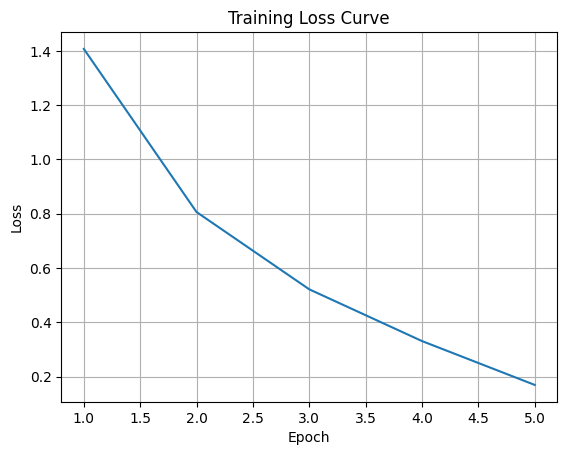

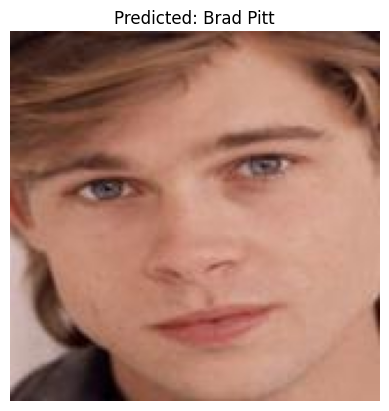

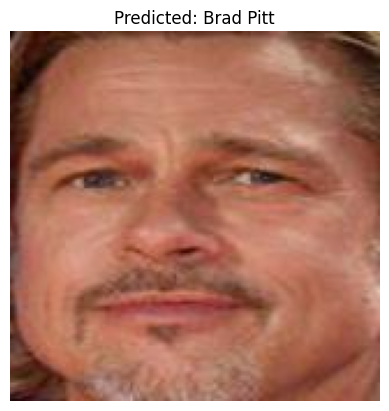

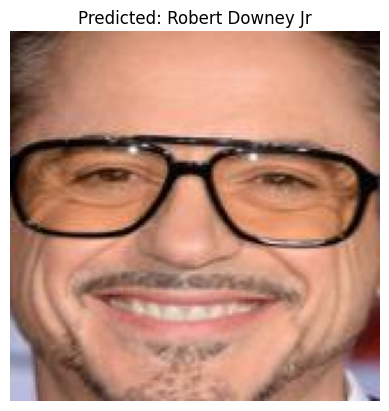

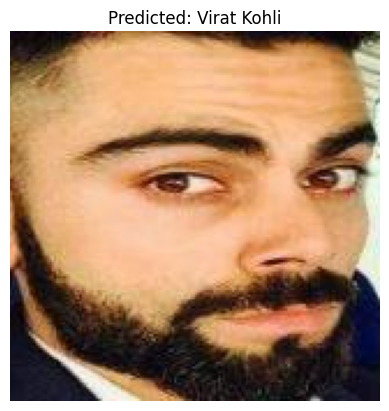

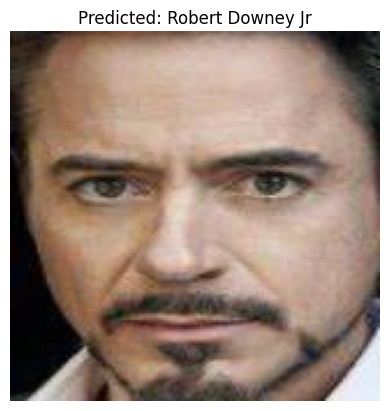

In [2]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "/kaggle/input/facerecognitioncnn/Faces"
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

label_map = {
    0: "Amitabh Bachchan",
    1: "Brad Pitt",
    2: "Virat Kohli",
    3: "Robert Downey Jr",
    4: "Dwayne Johnson"
}

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model = SimpleCNN(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 5
losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "face_classifier_cnn.pth")
print("Model saved as face_classifier_cnn.pth")

plt.plot(range(1, epochs+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

class_dirs = os.listdir(data_dir)

for i in range(5):
    chosen_class = random.choice(class_dirs)
    image_file = random.choice(os.listdir(os.path.join(data_dir, chosen_class)))
    image_path = os.path.join(data_dir, chosen_class, image_file)
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)
        predicted_name = label_map[pred.item()]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_name}")
    plt.show()
